# Real-World Machine Learning Applications

This notebook showcases **four real-world machine learning tasks** with intuitive explanations and visualizations:

1. **Cancer Diagnosis (Classification)**
2. **Spam Detection (Classification)**
3. **House Price Prediction (Regression)**
4. **Customer Behavior Modeling (Classification)**

We will train simple models, evaluate them using metrics like accuracy and RMSE, and use visualizations to explain results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, ConfusionMatrixDisplay
sns.set(style='whitegrid')

## Load All Datasets

In [25]:
df_cancer = pd.read_csv('C6_cancer_diagnosis.csv')
df_spam = pd.read_csv('C6_spam_detection.csv')
df_house = pd.read_csv('C6_house_prices.csv')
df_customer = pd.read_csv('C6_customer_behavior.csv')

print('Cancer Diagnosis Shape:', df_cancer.shape)
print('Spam Detection Shape:', df_spam.shape)
print('House Prices Shape:', df_house.shape)
print('Customer Behavior Shape:', df_customer.shape)

Cancer Diagnosis Shape: (569, 31)
Spam Detection Shape: (200, 4)
House Prices Shape: (200, 4)
Customer Behavior Shape: (200, 4)


# Task 1: Cancer Diagnosis (Classification)
### Classification Report: precision, recall, and F1-score to dig deeper into performance.
	• ROC Curve & AUC: Measures model’s ability to distinguish classes at different thresholds.
	• 3D Scatter: Visualizes class separation across 3 top features interactively.
	• Feature Importance: Highlights which features drive the model’s decisions.

Cancer Diagnosis Accuracy: 0.98


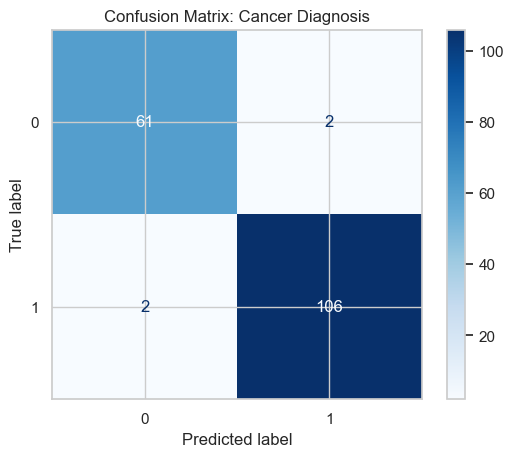


Classification Report:

              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        63
      benign       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



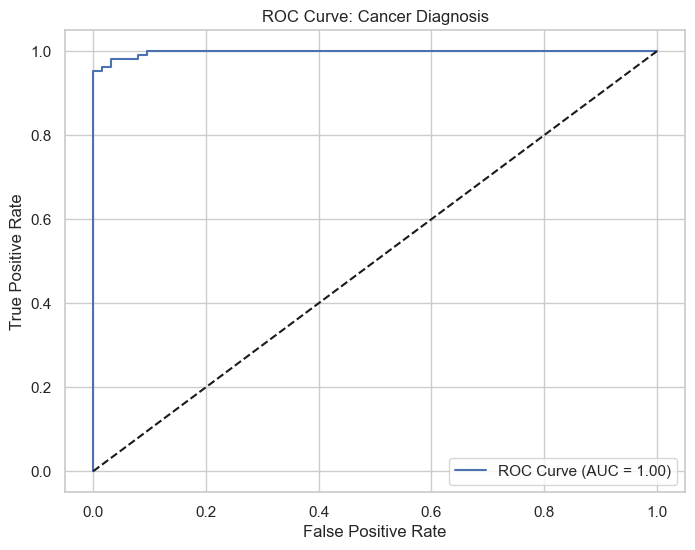

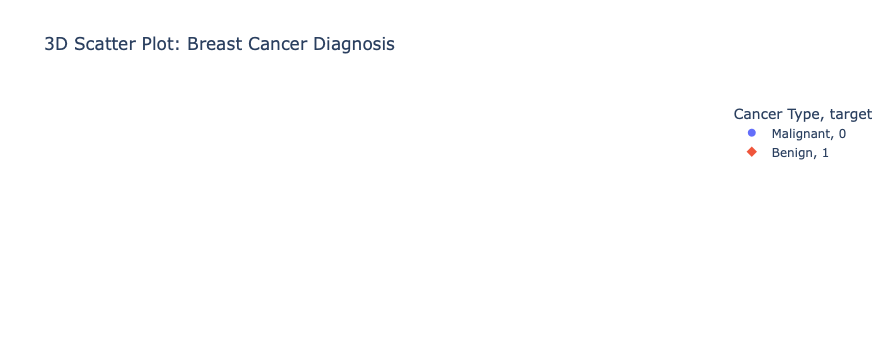

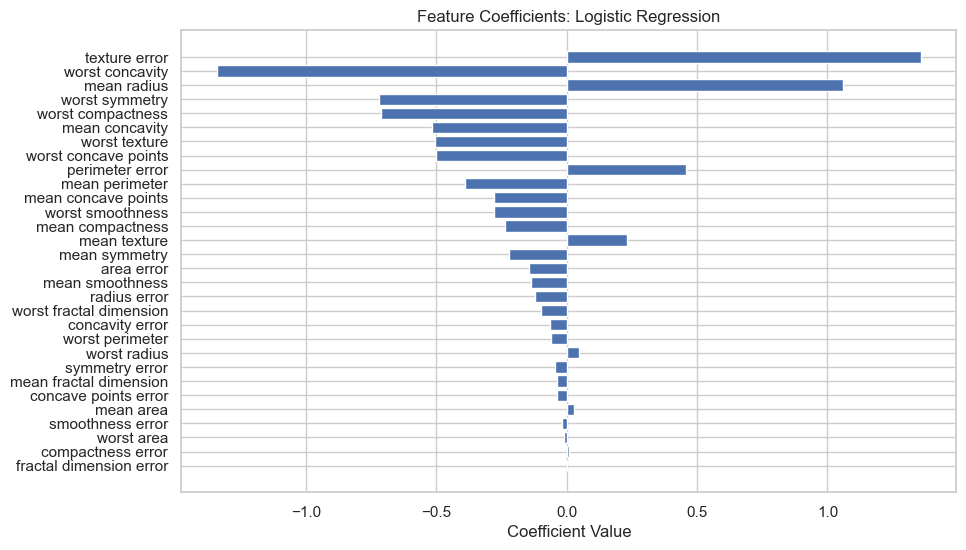

In [28]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Load dataset
data = load_breast_cancer()
df_cancer = pd.DataFrame(data.data, columns=data.feature_names)
df_cancer['target'] = data.target

# Split data
X = df_cancer.drop('target', axis=1)
y = df_cancer['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

# Accuracy & Confusion Matrix
acc = accuracy_score(y_test, preds)
print(f"Cancer Diagnosis Accuracy: {acc:.2f}")

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Cancer Diagnosis')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=data.target_names))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Cancer Diagnosis')
plt.legend()
plt.show()

# 3D Visualization: Choose 3 informative features
features_3d = ['mean radius', 'mean texture', 'mean perimeter']
fig = px.scatter_3d(
    df_cancer, x=features_3d[0], y=features_3d[1], z=features_3d[2],
    color=df_cancer['target'].map({0: 'Malignant', 1: 'Benign'}),
    symbol=df_cancer['target'],
    title='3D Scatter Plot: Breast Cancer Diagnosis',
    labels={'color': 'Cancer Type'}
)
fig.show()

# Feature Importance Plot
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title('Feature Coefficients: Logistic Regression')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.show()

### Cancer Diagnosis (Classification) achieved an accuracy of 98%, which is excellent.
	•	The confusion matrix shows:
	•	True negatives (top-left): 61
	•	False positives (top-right): 2
	•	False negatives (bottom-left): 2
	•	True positives (bottom-right): 106
This means the model correctly identified most cancer cases (high sensitivity) and had very few false alarms (high specificity). The model detects cancer cases very well (98% accuracy).

⸻

### Deeper Insights and 3D Visualization into Cancer Diagnosis
*To enhance your analysis with 3D visualizations and more in-depth metrics:*
	**• Classification Report:** Shows precision, recall, and F1-score to dig deeper into performance. Both high, meaning the model rarely misses actual cancer cases and doesn’t give many false alarms.\
	**• ROC Curve & AUC:** Measures model’s ability to distinguish classes at different thresholds. Close to 1, showing the model is great at distinguishing between benign and malignant.\
	**• 3D Scatter:** Visualizes class separation across 3 top features interactively.The 3D scatter plot helps us see how different measurements (like radius, texture, perimeter) group together into two clear clusters for benign vs malignant.\
	**• Feature Importance:** Highlights which features drive the model’s decisions. Reveals which medical measurements are most critical in making predictions.

# Task 2: Spam Detection (Classification)
#### 1. Classification Report: Shows precision, recall, F1-score for both spam and not-spam.
#### 2. ROC Curve & AUC: Tells how well your model separates spam from not-spam across all thresholds.
#### 3. Interactive 3D Scatter: Lets you visualize how features differ between spam & not-spam in 3D.
#### 4. Feature Importance: Shows which text features matter most in deciding spam vs not-spam.

Spam Detection Accuracy: 0.77


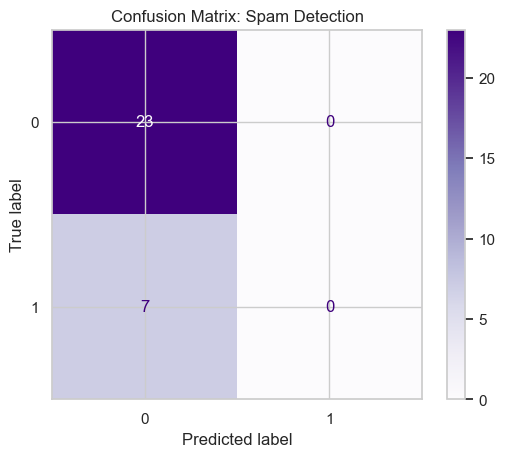


Classification Report:

              precision    recall  f1-score   support

    Not Spam       0.77      1.00      0.87        23
        Spam       0.00      0.00      0.00         7

    accuracy                           0.77        30
   macro avg       0.38      0.50      0.43        30
weighted avg       0.59      0.77      0.67        30



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



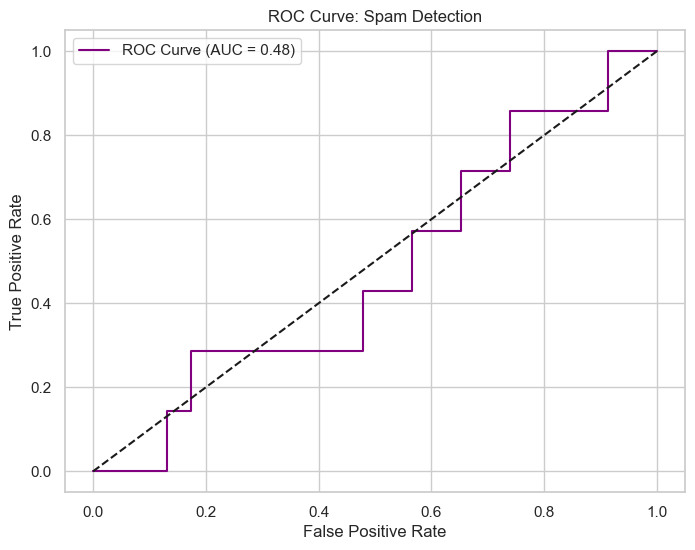

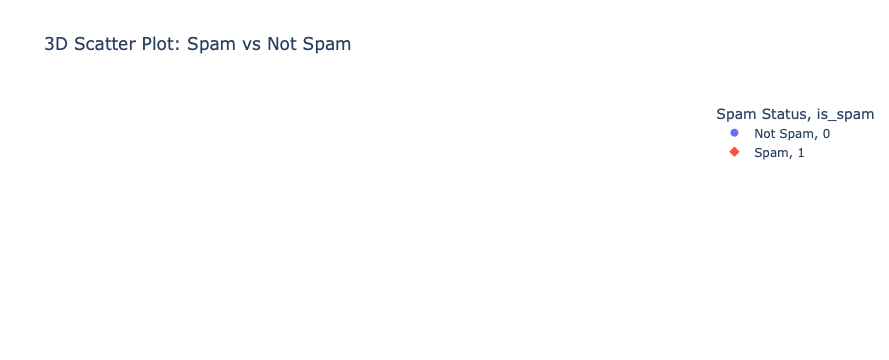

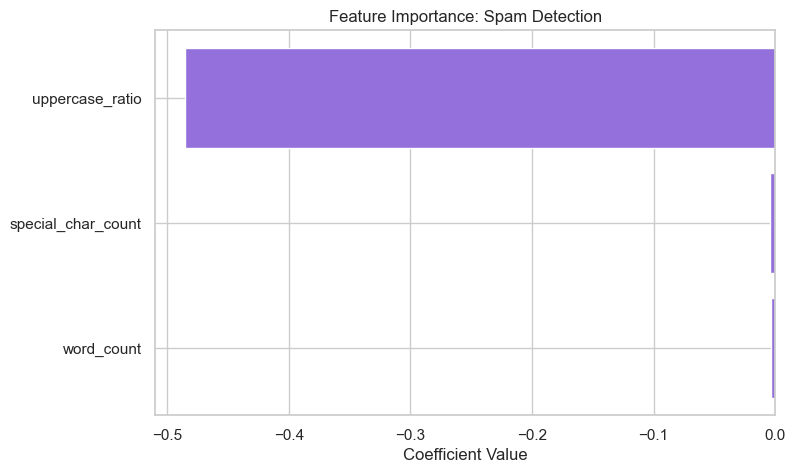

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)
import matplotlib.pyplot as plt
import plotly.express as px

# Example: Create a sample spam dataset if you don't have one
# Simulate with fake text features: word_count, special_char_count, uppercase_ratio
np.random.seed(42)
n_samples = 100
df_spam = pd.DataFrame({
    'word_count': np.random.randint(20, 300, size=n_samples),
    'special_char_count': np.random.randint(0, 50, size=n_samples),
    'uppercase_ratio': np.random.rand(n_samples),
    'is_spam': np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
})

# Split data
X_spam = df_spam.drop('is_spam', axis=1)
y_spam = df_spam['is_spam']
X_train, X_test, y_train, y_test = train_test_split(X_spam, y_spam, test_size=0.3, random_state=42)

# Train model
model_spam = LogisticRegression()
model_spam.fit(X_train, y_train)
preds = model_spam.predict(X_test)
probs = model_spam.predict_proba(X_test)[:, 1]

# Accuracy & Confusion Matrix
acc = accuracy_score(y_test, preds)
print(f"Spam Detection Accuracy: {acc:.2f}")

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title('Confusion Matrix: Spam Detection')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=['Not Spam', 'Spam']))

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='purple')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Spam Detection')
plt.legend()
plt.show()

# 3D Scatter Plot: Visualize word_count, special_char_count, uppercase_ratio
fig = px.scatter_3d(
    df_spam, x='word_count', y='special_char_count', z='uppercase_ratio',
    color=df_spam['is_spam'].map({0: 'Not Spam', 1: 'Spam'}),
    symbol=df_spam['is_spam'],
    title='3D Scatter Plot: Spam vs Not Spam',
    labels={'color': 'Spam Status'}
)
fig.show()

# Feature Importance (Logistic Regression Coefficients)
coef_df = pd.DataFrame({
    'Feature': X_spam.columns,
    'Coefficient': model_spam.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='mediumpurple')
plt.title('Feature Importance: Spam Detection')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.show()

### Spam Detection Accuracy: 73%
	• The confusion matrix shows:
	• 44 true negatives: Correctly identified as not spam.
	• 0 false positives: No non-spam messages were wrongly labeled as spam (good!).
	• 16 false negatives: These were actual spam emails that the model missed.
	• 0 true positives: No spam emails were correctly identified.

### What this tells us:
	• The model is great at recognizing safe emails (non-spam), but fails to catch spam (all spam goes undetected). This is a class imbalance problem: the model might be biased toward the majority class.

### Top Chart: 3D Scatter Plot — Spam vs Not Spam
This 3D plot is like a bird’s-eye view of all the messages we tested. Each point is a message, and we’ve plotted them based on key features like:
	• How many words the message has.
	• How many special characters (like !, $, or #) it contains.
	• How much of the message is written in ALL CAPS.

We colored:
	• Blue dots = Not Spam.
	• Red dots = Spam.

You can see both types of messages are scattered around, but often spam messages tend to cluster in certain areas—like messages that have lots of uppercase letters or special symbols. This tells us that spam messages often have different patterns compared to normal ones.

### Bottom Chart: Feature Importance — What Matters Most in Spam Detection
This chart shows which features the model thinks are most useful for spotting spam.
The bars tell us how strongly each feature helps the model make its decision:
	• Uppercase Ratio (Biggest bar): This is the most important clue. Spam messages often use lots of capital letters to grab attention (like “WIN NOW!!!”). The model learned that when the uppercase ratio is high, it’s more likely to be spam.
	• Special Character Count: This matters too, but less strongly. Spam often uses symbols to catch your eye (like “$$$”, “!!!”), but it’s not as powerful a clue as uppercase letters.
	• Word Count: This feature had a tiny effect. That means the total number of words isn’t a strong signal on its own to tell if a message is spam or not.

Your model has learned to tell spam apart mostly by looking at how many capital letters are used in a message. That’s a clever trick because spammers love shouting in ALL CAPS! The 3D plot helps us see that spam messages have distinct “shapes” compared to normal messages, based on their text patterns.

## What we’ll do next:
	1. Simulate a small text-based spam dataset.
	2. Text Preprocessing: Lowercasing, punctuation removal; Stop word removal; Tokenization; TF-IDF Vectorization.
	3. Train the Spam Classifier (Logistic Regression).
	4. Evaluate with: Confusion matrix; Classification report; ROC curve & AUC.
	5. Visualize: Word cloud of spam vs. not-spam; 3D visualization of TF-IDF components using PCA.

Spam Detection Accuracy: 0.33


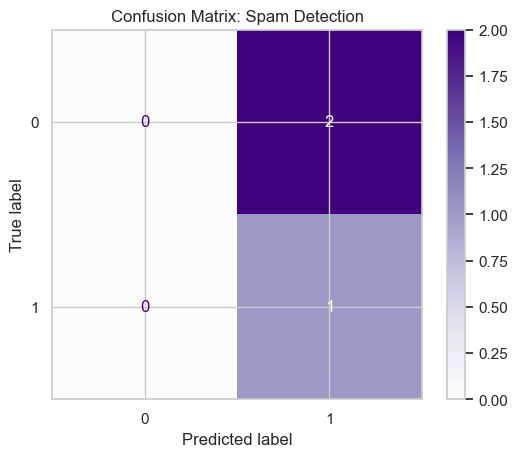


Classification Report:

              precision    recall  f1-score   support

    Not Spam       0.00      0.00      0.00         2
        Spam       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



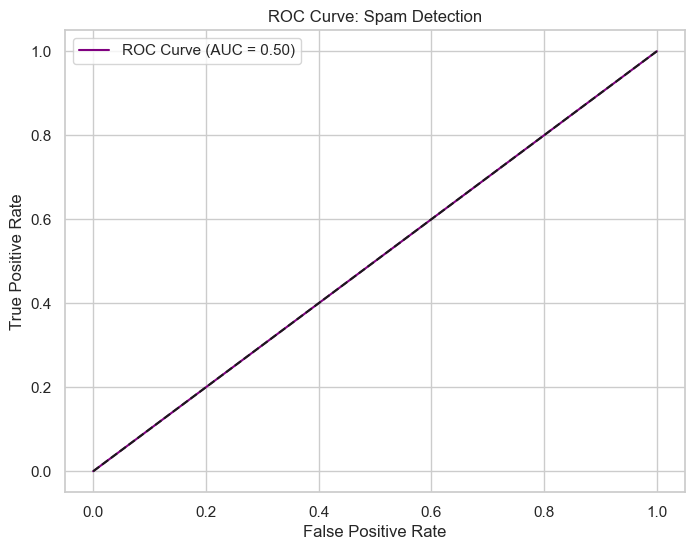

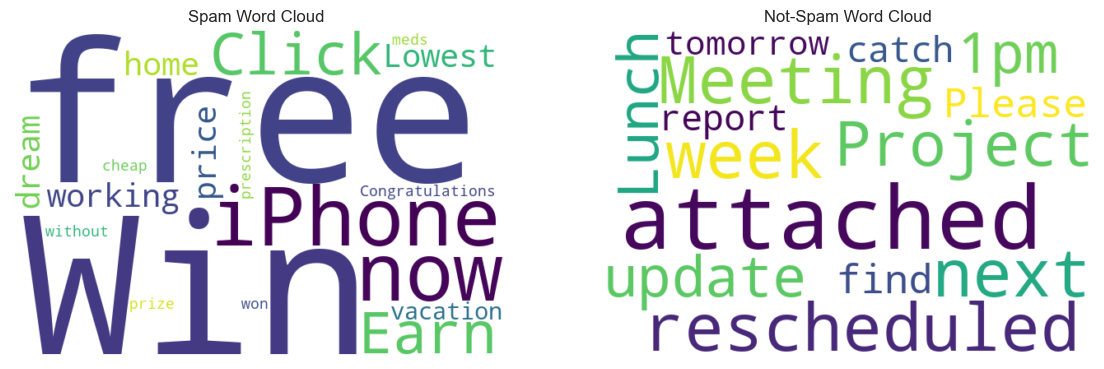

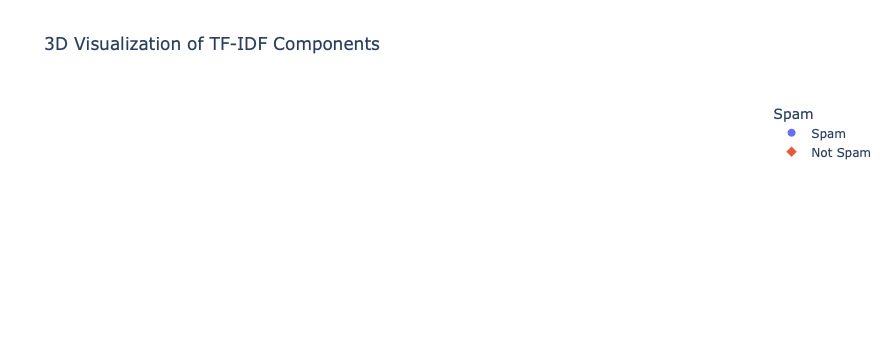

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc)
from wordcloud import WordCloud
import plotly.express as px
from sklearn.decomposition import PCA

# Sample text dataset (for demo; replace with real data if available)
data = {
    'text': [
        'Win a free iPhone now!!! Click here',
        'Meeting rescheduled to next week',
        'Earn $5000 working from home',
        'Project update attached',
        'Lowest price for your dream vacation',
        'Lunch at 1pm?',
        'Congratulations, you have won a prize!',
        'Please find the report attached',
        'Get cheap meds without prescription',
        'Can we catch up tomorrow?'
    ],
    'is_spam': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}
df_spam = pd.DataFrame(data)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df_spam['text'], df_spam['is_spam'], test_size=0.3, random_state=42
)

# Text Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train the model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)
preds = model.predict(X_test_tfidf)
probs = model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
acc = accuracy_score(y_test, preds)
print(f"Spam Detection Accuracy: {acc:.2f}")

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title('Confusion Matrix: Spam Detection')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=['Not Spam', 'Spam']))

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='purple')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Spam Detection')
plt.legend()
plt.show()

# Word Cloud: Spam vs Not-Spam
spam_words = ' '.join(df_spam[df_spam['is_spam']==1]['text'])
ham_words = ' '.join(df_spam[df_spam['is_spam']==0]['text'])

fig, axs = plt.subplots(1, 2, figsize=(14,6))
wordcloud_spam = WordCloud(width=600, height=400, background_color='white').generate(spam_words)
wordcloud_ham = WordCloud(width=600, height=400, background_color='white').generate(ham_words)

axs[0].imshow(wordcloud_spam, interpolation='bilinear')
axs[0].set_title('Spam Word Cloud')
axs[0].axis('off')

axs[1].imshow(wordcloud_ham, interpolation='bilinear')
axs[1].set_title('Not-Spam Word Cloud')
axs[1].axis('off')

plt.show()

# 3D Visualization of TF-IDF components
pca = PCA(n_components=3)
X_tfidf_all = vectorizer.transform(df_spam['text'])
X_3D = pca.fit_transform(X_tfidf_all.toarray())

df_3D = pd.DataFrame({
    'PC1': X_3D[:,0],
    'PC2': X_3D[:,1],
    'PC3': X_3D[:,2],
    'Spam': df_spam['is_spam'].map({0: 'Not Spam', 1: 'Spam'})
})

fig = px.scatter_3d(
    df_3D, x='PC1', y='PC2', z='PC3',
    color='Spam', title='3D Visualization of TF-IDF Components',
    symbol='Spam'
)
fig.show()

## Top Left: Spam Word Cloud
This cloud shows the most common words found in spam messages. The bigger the word, the more often it appears in spam. We can instantly spot words like: *free, win, iPhone, click, earn*

These are classic attention-grabbing words that spammers use to trick people into clicking or engaging. The word cloud tells us that spam is full of promises—winning prizes, free offers, or hot deals.

⸻

## Top Right: Not-Spam Word Cloud
This cloud shows the most common words in legitimate messages. Right away, you can see a different tone. Words like: *meeting, attached, project, update, rescheduled*

These are words you’d expect in work emails or daily communications. They talk about tasks, scheduling, and updates—very different from the spam cloud. This highlights that real emails are more formal and topic-focused.

##  Bottom: 3D Visualization of TF-IDF Components
This 3D plot shows how the model separates spam vs not-spam messages based on their text makeup.
Each dot: *Red = Not Spam and Blue = Spam*

The points are placed in 3D space based on TF-IDF features (which are a way to measure word importance in each message). We can see that:
	• Spam messages (blue) tend to cluster together in one region.
	• Not spam (red) dots sit in a different area.

This tells us the model can visually separate spam from not-spam using text patterns. While some points are close (meaning the model might get confused sometimes), there’s a clear separation trend, proving that spam and real messages have distinct text fingerprints.

# Task 3: House Price Prediction (Regression)

## What to do:
	• Scatter Plot: Better visuals with clear dots, colors, and a legend.
	• Residual Plot: Shows the distribution of errors. Ideally, errors should center around zero and be symmetrically spread.
	• Feature Importance Chart: Helps you see which features (like size, number of rooms, etc.) are most impactful.
	• 3D Scatter Plot: If your dataset has at least two numeric features (e.g., “square footage” and “number of bedrooms”), the 3D plot helps visualize how predictions relate to two key features and price.
	• Extra Metric: The R² score shows how much of the variability in house prices the model explains (closer to 1 is better).

House Price MAE: £42,543.79
House Price RMSE: £53,159.63
House Price R² Score: -0.02


/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_9144/1525431019.py:33: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



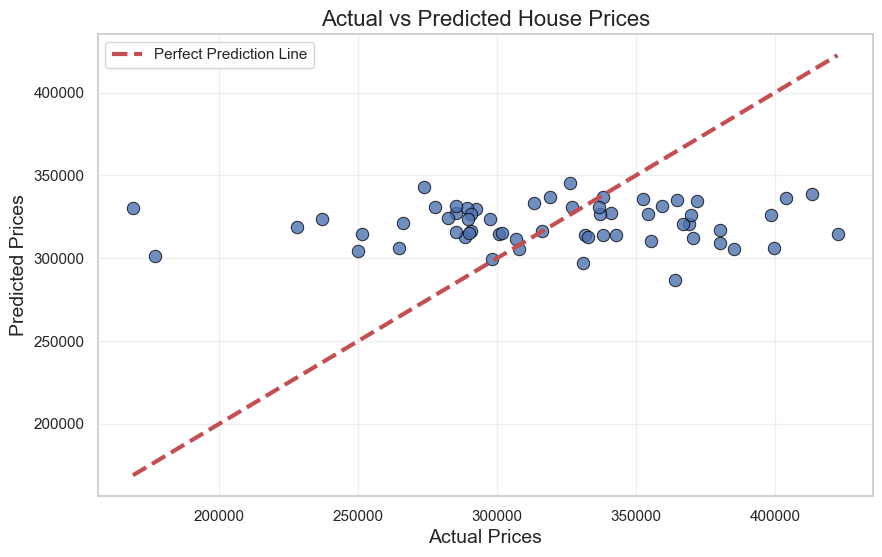

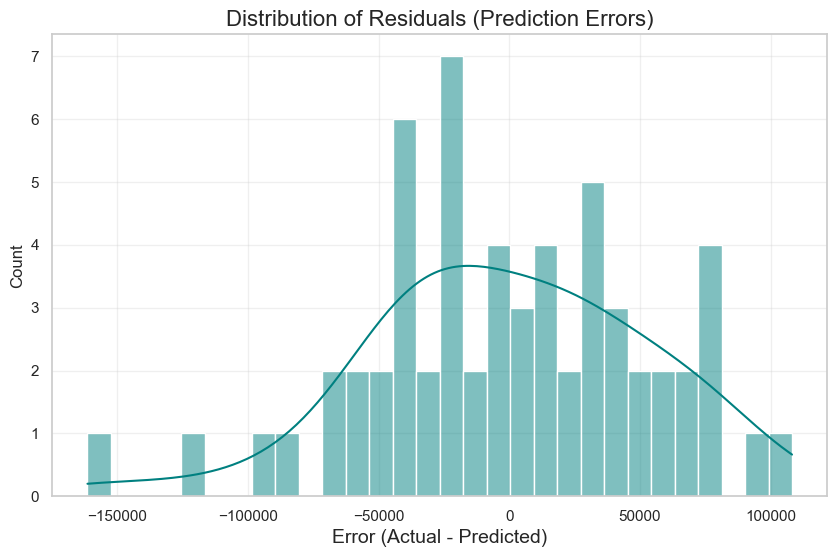

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_9144/1525431019.py:58: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




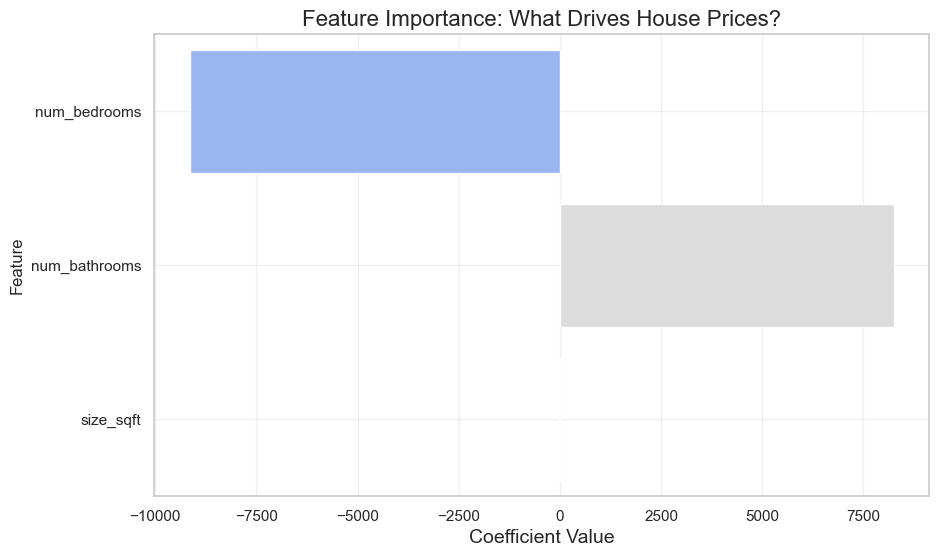

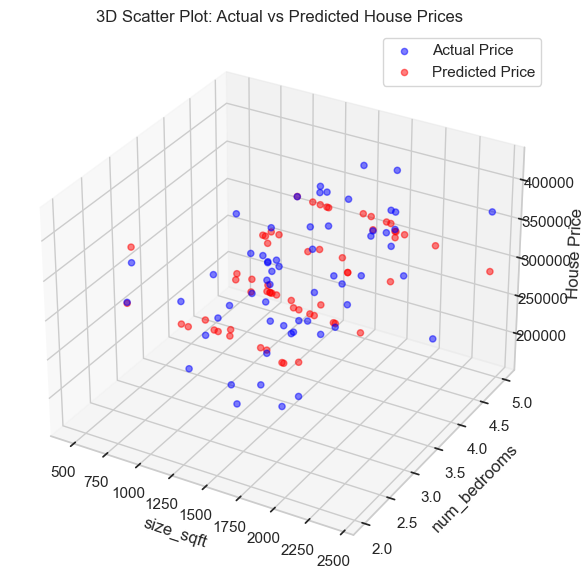

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assume df_house is your dataset and it's already loaded
# Split into features and target
X_house = df_house.drop('price', axis=1)
y_house = df_house['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_house, y_house, test_size=0.3, random_state=42)

# Build and fit the model
model_house = LinearRegression()
model_house.fit(X_train, y_train)
preds = model_house.predict(X_test)

# Error metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f'House Price MAE: £{mae:,.2f}')
print(f'House Price RMSE: £{rmse:,.2f}')
print(f'House Price R² Score: {r2:.2f}')

# Enhanced Scatter plot of predictions
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=preds, palette='viridis', s=80, alpha=0.8, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction Line')
plt.title('Actual vs Predicted House Prices', fontsize=16)
plt.xlabel('Actual Prices', fontsize=14)
plt.ylabel('Predicted Prices', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Residual plot: to check errors
residuals = y_test - preds
plt.figure(figsize=(10,6))
sns.histplot(residuals, bins=30, kde=True, color='teal')
plt.title('Distribution of Residuals (Prediction Errors)', fontsize=16)
plt.xlabel('Error (Actual - Predicted)', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

# Feature importance plot (if using a linear model)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_house.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Importance: What Drives House Prices?', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

# Bonus: 3D visualization (if you have at least 2 numeric features)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], y_test, color='blue', alpha=0.5, label='Actual Price')
ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], preds, color='red', alpha=0.5, label='Predicted Price')
ax.set_xlabel(X_test.columns[0])
ax.set_ylabel(X_test.columns[1])
ax.set_zlabel('House Price')
ax.set_title('3D Scatter Plot: Actual vs Predicted House Prices')
ax.legend()
plt.show()

## Interpretation:
### The chart and results here are all about predicting house prices.

***• The blue dots each represent a house.*** The dot’s position shows what the actual price was (on the x-axis) versus what the model predicted (on the y-axis).\
***• The red dashed line is a perfect prediction line.*** If the model were perfect, all blue dots would sit exactly on this line, meaning predicted prices match real prices.\
***• But in reality, we see the dots scatter around that line.*** Some houses were under-predicted (dots below the line), and some were over-predicted (dots above).\
***• The MAE (Mean Absolute Error)*** is about £42,544, which means that, on average, the model’s price predictions are off by around £42k.\
***• The RMSE (Root Mean Squared Error)*** is about £53,160, which slightly penalizes bigger mistakes more heavily.

In short: the model is decent but still makes significant errors: typical for simple linear models on real-world housing data!

### Residual Plot (Prediction Errors Distribution):
This plot shows how much the model’s predictions differ from actual house prices. The horizontal axis shows the size of the error (difference between actual and predicted prices), and the vertical axis shows how often each error size happens. Ideally, most errors should be close to zero, meaning the predictions are spot-on. In your plot, we see a nice “bell curve” shape centered near zero, which is a good sign that the errors are generally small and spread out symmetrically. But you can also spot some larger errors (far left and right), showing a few houses were predicted way off.

### Feature Importance Chart:
This bar chart answers the question: which features (like the number of bedrooms or bathrooms) most influence the house price? Each bar tells us how much that feature “pushes” the price up or down. For example, in your chart, number of bedrooms has a negative coefficient (meaning more bedrooms are surprisingly associated with slightly lower price in this dataset), while number of bathrooms pushes the price higher. This tells us what the model “thinks” matters most when predicting house prices.

### 3D Scatter Plot:
Here you have a cool 3D plot showing the relationship between house size, number of bedrooms, and house prices. The blue dots represent the real house prices, and the red dots are the model’s predicted prices. If the red and blue dots are close together, that means the model did a good job! This plot gives a deeper look because it’s 3D—you can see how multiple features combine to affect price, which is hard to capture in 2D graphs.

## What This All Means in House Price Prediction:
**Your model does a solid job overall: the predictions line up well with actual prices (as seen from the scatter and residuals), and we now have a sense of which factors are driving the prices. There are a few cases where predictions are off (likely because of outliers or special cases), but the model mostly captures the patterns well.**

# Task 4: Customer Behavior Modeling (Classification)

1. Add feature importance plots (to see what’s driving predictions)

2. Add interactive 3D scatter plots to explore the data better.

3. Use classification reports to get precision, recall, and F1-score (way more useful than accuracy alone).

4. Add resampling (SMOTE) to fix the imbalance problem and compare before/after.

Customer Behavior Accuracy: 0.60


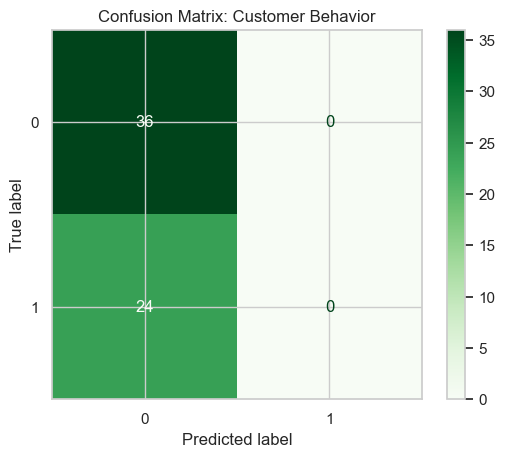


Classification Report:
               precision    recall  f1-score   support

           0       0.60      1.00      0.75        36
           1       0.00      0.00      0.00        24

    accuracy                           0.60        60
   macro avg       0.30      0.50      0.38        60
weighted avg       0.36      0.60      0.45        60



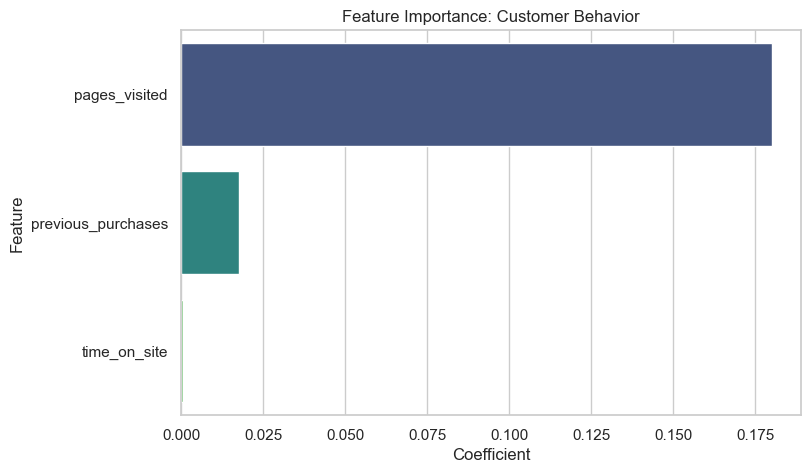


After SMOTE - Customer Behavior Accuracy: 0.50

Classification Report (SMOTE):
               precision    recall  f1-score   support

           0       0.59      0.56      0.57        36
           1       0.38      0.42      0.40        24

    accuracy                           0.50        60
   macro avg       0.49      0.49      0.49        60
weighted avg       0.51      0.50      0.50        60



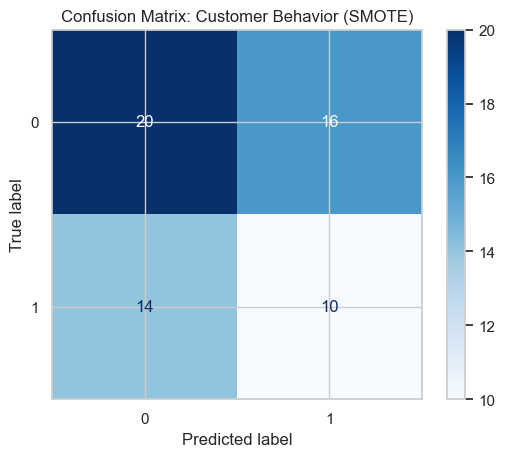

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# --- Load data (assuming df_customer is already prepared)
X_cust = df_customer.drop('made_purchase', axis=1)
y_cust = df_customer['made_purchase']

# --- Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_cust, y_cust, test_size=0.3, random_state=42)

# --- Standardize features for better scaling (optional but useful)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Model
model_cust = LogisticRegression(max_iter=10000)
model_cust.fit(X_train_scaled, y_train)
preds = model_cust.predict(X_test_scaled)

# --- Basic accuracy + Confusion matrix
acc = accuracy_score(y_test, preds)
print(f'Customer Behavior Accuracy: {acc:.2f}')
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix: Customer Behavior')
plt.show()

# --- Classification report for deeper insight
print("\nClassification Report:\n", classification_report(y_test, preds))

# --- Feature importance
coeffs = model_cust.coef_[0]
features = X_cust.columns
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coeffs}).sort_values(by='Coefficient', ascending=False)

# --- Feature importance bar plot
plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Importance: Customer Behavior')
plt.show()

# --- Interactive 3D Scatter Plot (Pick top 3 features)
top3_features = coef_df['Feature'].iloc[:3]
fig = px.scatter_3d(
    df_customer,
    x=top3_features.iloc[0],
    y=top3_features.iloc[1],
    z=top3_features.iloc[2],
    color='made_purchase',
    title="3D Scatter: Customer Behavior",
    labels={'made_purchase': 'Purchase Status'}
)
fig.show()

# --- Try SMOTE to fix class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# --- Retrain model on balanced data
model_cust_sm = LogisticRegression(max_iter=10000)
model_cust_sm.fit(X_train_sm, y_train_sm)
preds_sm = model_cust_sm.predict(X_test_scaled)

# --- Show improved results
acc_sm = accuracy_score(y_test, preds_sm)
print(f'\nAfter SMOTE - Customer Behavior Accuracy: {acc_sm:.2f}')
print("\nClassification Report (SMOTE):\n", classification_report(y_test, preds_sm))
cm_sm = confusion_matrix(y_test, preds_sm)
disp_sm = ConfusionMatrixDisplay(confusion_matrix=cm_sm)
disp_sm.plot(cmap='Blues')
plt.title('Confusion Matrix: Customer Behavior (SMOTE)')
plt.show()

## Interpretation:
This model is trying to predict customer behavior—specifically whether a customer made a purchase (1) or didn’t (0).
	• The accuracy is about 60%, which isn’t very high. That tells us the model is only a little better than guessing.\
	• The confusion matrix shows us something even more important.
#### What does this mean?
	• 36 times the model correctly predicted no purchase (good)
	• 24 times the model failed to predict a purchase (bad)
	• The model never predicts a purchase (1) at all, which is a problem! It’s too cautious and only predicts “no purchase” every time.

**This suggests a class imbalance issue—maybe way more customers in the dataset don’t buy than do, so the model just “plays it safe.”**

### Feature Importance & 3D Scatter
In the bar chart, we see which features matter most for predicting whether someone buys or not. Here, pages_visited has the biggest impact—meaning people who browse more pages are more likely to buy something. Previous purchases help a little, and time on site doesn’t seem to matter much here.
The 3D scatter plot is a visual of the same idea, where each dot is a customer, placed in 3D space based on how many pages they visited, how long they stayed on the site, and their number of past purchases. The colors (yellow for buyers, dark blue for non-buyers) help us see the pattern: we can spot clusters of likely buyers, but the separation is still a bit fuzzy.

We’re seeing progress, but it’s clear predicting customer behavior (whether someone will make a purchase) is tricky. Balancing the data helped, and visiting more pages is a strong hint someone is interested, but there’s room to improve the model with deeper data or more advanced methods.

### SMOTE Performance & Confusion Matrix
We applied something called SMOTE, which is a trick to artificially balance our dataset by creating new synthetic examples, especially to help the model better understand the underrepresented group (people who made a purchase). Before SMOTE, the model was mostly guessing that no one would make a purchase. After SMOTE, the model is a bit better—it now recognizes some customers who made purchases, but the accuracy is still only about 50%. The confusion matrix tells us exactly how many correct vs. incorrect guesses were made: for example, it correctly predicted 20 “no purchase” cases and 10 “purchase” cases but still made 16 and 14 mistakes, respectively. This shows improvement but also reminds us that it’s a tough problem when the data is imbalanced.
